In [49]:
import pandas as pd
import numpy as np
import measure as ms    # measure.py

In [50]:
class Logistic:
    def __init__(self, filePath):
        self.data = pd.read_csv(filePath)
        self.preprocess()
        self.split_data()

    
    def preprocess(self):
        self.data = self.data.sample(frac=1)
                
        self.X = self.data.drop(columns='target').to_numpy()
        self.Y = self.data.filter(like='target').to_numpy()

        self.X = (self.X - self.X.mean(axis = 0)) / self.X.std(axis = 0)

    
    def split_data(self):
        self.split_index = int(0.8 * self.X.shape[0])
        
        self.X_train = self.X[:self.split_index]
        self.X_test  = self.X[self.split_index:]
        
        self.Y_train = self.Y[:self.split_index]
        self.Y_test  = self.Y[self.split_index:]
        

    def logistic(self, x):
        return 1 / (1 + np.exp(-x))


    def train(self):
        def gradient(X, y, w, b, l):
            m, n = X.shape
            y_pred = self.logistic(np.matmul(X, w) + b * np.ones((m, 1)))
            grad_w = np.matmul(np.transpose(X), y_pred - y) / m
            grad_b = np.sum(y_pred - y) / m

            grad_w += (l / m) * w

            return grad_w, grad_b

        #initialize weights and bias
        n = self.X_train.shape[1]
        #self.w = np.array([8.0, -824.0, 505.0, -10.0, -4.0, -152.0, 221.0, 17.0, -606.0, -411.0, 196.0, -425, -490.0]).reshape(n, 1)
        self.w = np.zeros((n, 1))
        self.b = 0.0

        #set learning rate
        a = 0.001

        #set L2 regularization parameter
        l = 1

        #set iterations
        epochs = 100000

        for i in range(epochs):
            grad_w, grad_b = gradient(self.X_train, self.Y_train, self.w, self.b, l)
            self.w += -a * grad_w
            self.b += -a * grad_b
            if (i + 1) % 5000 == 0:
                print(f"Iteration {i+1}/{epochs} ({(i+1)/epochs * 100}%)")
        
        print("Final weights:",self.w)
        print("Final bias:",self.b)


    def predict(self):
        predictions = [self.predict_single(x) for x in self.X_test]
        return np.array(predictions)

        
    def predict_single(self, x):
        xvec = np.atleast_2d(x)
        v = np.dot(xvec, self.w) + self.b
        return 1 if self.logistic(v) >= 0.5 else 0


Iteration 5000/100000 (5.0%)
Iteration 10000/100000 (10.0%)
Iteration 15000/100000 (15.0%)
Iteration 20000/100000 (20.0%)
Iteration 25000/100000 (25.0%)
Iteration 30000/100000 (30.0%)
Iteration 35000/100000 (35.0%)
Iteration 40000/100000 (40.0%)
Iteration 45000/100000 (45.0%)
Iteration 50000/100000 (50.0%)
Iteration 55000/100000 (55.00000000000001%)
Iteration 60000/100000 (60.0%)
Iteration 65000/100000 (65.0%)
Iteration 70000/100000 (70.0%)
Iteration 75000/100000 (75.0%)
Iteration 80000/100000 (80.0%)
Iteration 85000/100000 (85.0%)
Iteration 90000/100000 (90.0%)
Iteration 95000/100000 (95.0%)
Iteration 100000/100000 (100.0%)
Final weights: [[-0.08994709]
 [-0.76428103]
 [ 0.78480895]
 [-0.24621074]
 [-0.27041049]
 [-0.03623589]
 [ 0.1962073 ]
 [ 0.47133833]
 [-0.4156078 ]
 [-0.5932896 ]
 [ 0.34229734]
 [-0.70457641]
 [-0.53761557]]
Final bias: -0.045985417119506614


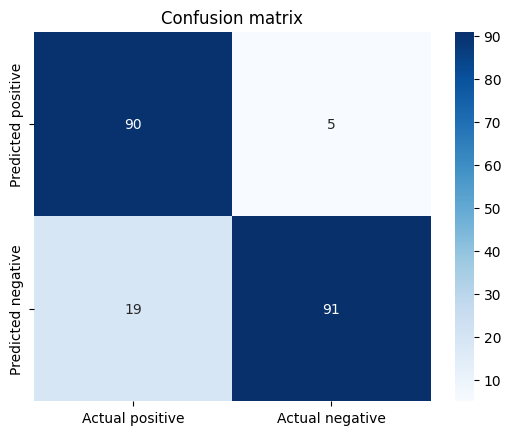

Accuracy: 0.88
Precision: 0.83
Recall: 0.95
Specificity: 0.83
F1 score: 0.88


In [51]:
if __name__ == "__main__":
    lc = Logistic("dataset/heart.csv")
    lc.train()
    predictions = lc.predict()
    tp, fp, fn, tn = ms.getConfusionMatrixEntries(predictions, lc.Y_test)
    ms.confusionMatrix(tp, fp, fn, tn)